In [3]:
from pathlib import Path
import pandas as pd
import json
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pickle
from datasets import load_dataset

/gpfs/data/chopralab/singhr36/miniconda/envs/sal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from read_outputs import read_results, load_mc_harm_estimates, judge_threshold_ablation, make_log_log_plots

In [34]:
def load_metadata_model_logs(model_log_path):
    model_comparison_arr_path = model_log_path / "model_comparison.pkl"
    metadata_path = model_log_path / "metadata.json"
    
    with open(model_comparison_arr_path, 'rb') as f:
        model_comparison_arr = pickle.load(f)
    
    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    return metadata, model_comparison_arr

In [40]:
def plot_mc_is(metadata, model_comparison_arr, ax, threshold=0.3):
    mc_arr = []
    is_arr = []
    
    for idx in range(len(model_comparison_arr['threshold_mc_means'])):
        mc_arr.append(model_comparison_arr['threshold_mc_means'][idx][threshold])
        is_arr.append(model_comparison_arr['threshold_is_means'][idx][threshold])
    
    
    ax.scatter(is_arr, mc_arr)
    ax.set_title(f"Base Model Interpolation {metadata['base_model_interpolation']}, Proposal {metadata['proposal_model']}")
    ax.plot(np.linspace(0, 1, 100), np.linspace(0,1,100))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("IS Threshold")
    ax.set_ylabel("MC Threshold")
    
    # plt.show()
    # plt.close()

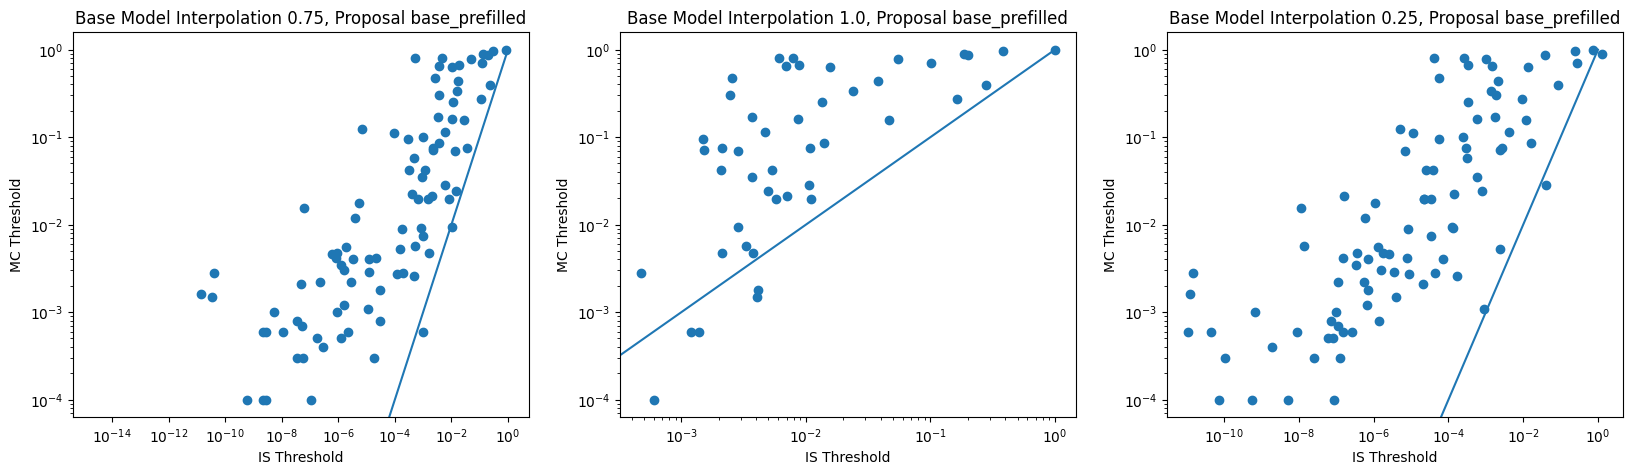

In [48]:
model_log_paths = [
    # Path("/gpfs/data/ranganathlab/singhr36/rare-generations/model_outputs/Llama-3.2-1B-Instruct/20250826_210945"),
    Path("/gpfs/data/ranganathlab/singhr36/rare-generations/model_outputs/Llama-3.2-1B-Instruct/20250827_053433"),
    Path("/gpfs/data/ranganathlab/singhr36/rare-generations/model_outputs/Llama-3.2-1B-Instruct/20250827_080849"),
    Path("/gpfs/data/ranganathlab/singhr36/rare-generations/model_outputs/Llama-3.2-1B-Instruct/20250827_030011"),    
]

fig, ax = plt.subplots(1, 3, figsize=(20, 5), dpi=100)

for idx, model_log_path in enumerate(model_log_paths):
    metadata, model_comparison_arr = load_metadata_model_logs(model_log_path)
    plot_mc_is(metadata, model_comparison_arr, threshold=0.2, ax=ax[idx])

plt.show()
plt.close()

In [11]:
len(mc_arr)

100